#**Modelling and Evaluation**

##**1. Setup and Load**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, accuracy_score
)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
# Load the feature-engineered datasets from Notebook 03
X_train = pd.read_csv('X_train_final.csv')
X_test = pd.read_csv('X_test_final.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train shape: (475714, 16)
Test shape: (118929, 16)
Train fraud rate: 0.012108115380249477
Test fraud rate: 0.012108064475443332


### Setup & Load (Interpretation)

**Result**: The feature-engineered datasets loaded successfully —
475,714 training rows and 118,929 test rows, both with 16 features.
Fraud rate is nearly identical between train (1.2108%) and test
(1.2108%) sets.

**Interpretation**: The near-perfect match in fraud rate between train
and test confirms the `stratify=y` parameter in the train-test split
(Notebook 03, Section 1) worked as intended — the class distribution was
preserved proportionally across both sets. This is an important sanity
check before modeling: without stratification, a random split could
have produced a test set with a meaningfully different (and less
representative) fraud rate, making evaluation results less reliable.

The dataset is confirmed ready for the baseline and tree-based model
comparisons that follow.

##**2. Baseline - Logistic Regression**

In [5]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg.predict(X_test)

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
pr_auc_lr = average_precision_score(y_test, y_proba_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression — ROC AUC: {roc_auc_lr:.4f}, "
      f"PR AUC: {pr_auc_lr:.4f}, Accuracy: {accuracy_lr:.4f}")

Logistic Regression — ROC AUC: 0.9935, PR AUC: 0.8168, Accuracy: 0.9809


### Baseline Model — Logistic Regression (Interpretation)

**Result**: The Logistic Regression baseline achieves ROC AUC = 0.9935,
PR AUC = 0.8168, and Accuracy = 0.9809.

**Interpretation**: This is a surprisingly strong baseline, especially
the PR AUC of 0.8168 — well above what a simple linear model would
typically achieve on a highly imbalanced fraud problem. This is
consistent with the EDA findings: `category` and `merchant` showed
near-complete fraud/non-fraud separation for a large share of
transactions (Sections 4 and 7), and `amount` showed minimal
distributional overlap between classes (Section 6) — these strong,
almost rule-like signals are easy for even a linear model to pick up.

The accuracy (0.9809) is not a meaningful
indicator of fraud-detection quality on its own — a trivial "always
predict non-fraud" model would already score ~0.9879. It is reported
here only for reference alongside the more relevant PR AUC.

**Implication for the tree-based models**: because the baseline is
already strong, the practical question for Random Forest, XGBoost, and
LightGBM is not just "can they beat Logistic Regression" but "by how
much, and is the added complexity (training time, interpretability
trade-off) justified by the improvement." This baseline result should
\

##**3. Handling Class Imbalamce with Smote**

In [6]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 469954, 1: 5760}
After SMOTE: {0: 469954, 1: 469954}


### Handling Class Imbalance with SMOTE (Interpretation)

**Result**: Before SMOTE, the training set had 469,954 non-fraud vs.
5,760 fraud cases (~1.21% fraud, matching the earlier reported rate).
After SMOTE, both classes are balanced at 469,954 each.

**Interpretation**: SMOTE generated 464,194 synthetic fraud samples
(469,954 − 5,760) to match the majority class size, resulting in a
fully balanced training set. This gives the tree-based models an equal
number of fraud and non-fraud examples to learn from, addressing the
severe class imbalance without discarding any real data (unlike
undersampling, which would have reduced the majority class instead).

**Important caveat to carry forward**: the test set remains untouched
at its original ~1.21% fraud rate — SMOTE was applied strictly to the
training data. All evaluation metrics in the following sections will
therefore reflect real-world class distribution, not the artificially
balanced training distribution. This is the correct approach to avoid
overly optimistic evaluation results.

##**4. Tree- Based Models: Random Forest, XGBoosts, LightGBM**

In [7]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, random_state=42, n_jobs=-1, verbose=-1
    )
}

trained_models = {}
results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - start

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    results[name] = {
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'accuracy': accuracy_score(y_test, y_pred),
        'train_time_sec': elapsed
    }
    trained_models[name] = model

    print(f"{name} — ROC AUC: {results[name]['roc_auc']:.4f}, "
          f"PR AUC: {results[name]['pr_auc']:.4f}, "
          f"Accuracy: {results[name]['accuracy']:.4f}, "
          f"Train time: {elapsed:.1f}s")

Random Forest — ROC AUC: 0.9958, PR AUC: 0.9084, Accuracy: 0.9958, Train time: 413.4s
XGBoost — ROC AUC: 0.9984, PR AUC: 0.9270, Accuracy: 0.9964, Train time: 19.8s
LightGBM — ROC AUC: 0.9908, PR AUC: 0.9046, Accuracy: 0.9955, Train time: 15.2s


### Tree-Based Models — Results (Interpretation)

**Result**: All three tree-based models outperform the Logistic
Regression baseline (PR AUC 0.8168) on PR AUC:

| Model | ROC AUC | PR AUC | Accuracy | Train Time |
|---|---|---|---|---|
| XGBoost | 0.9984 | **0.9270** | 0.9964 | 19.8s |
| Random Forest | 0.9958 | 0.9084 | 0.9958 | 413.4s |
| LightGBM | 0.9908 | 0.9046 | 0.9955 | **15.2s** |

**Interpretation**: XGBoost delivers the best performance on every
metric — highest ROC AUC, highest PR AUC (+0.11 over the baseline), and
highest accuracy — while also training over 20x faster than Random
Forest (19.8s vs. 413.4s). LightGBM is a close third on PR AUC but is
the fastest of all three models, making it a strong candidate if
training speed becomes a priority (e.g. frequent retraining in
production).

Random Forest's substantially longer training time (413.4s vs. ~15-20s
for the boosting-based models) did not translate into better
performance — it actually scored lowest on PR AUC among the three
tree-based models. This is a useful practical finding: given the
dataset's characteristics, gradient boosting methods (XGBoost,
LightGBM) achieve better results *and* far greater training efficiency
than bagging-based Random Forest here.

**Selection**: **XGBoost** will be carried forward as the best model for
threshold tuning and final evaluation in the following sections, based
on its top PR AUC score.

**Note on accuracy**: as previously flagged, accuracy is reported for
reference only and is not the basis for model selection — with a 1.21%
fraud rate, all four models (including the baseline) show accuracy
above 98%, which reflects the class imbalance more than genuine
fraud-detection capability.

##**5. Model Comparison Summary**

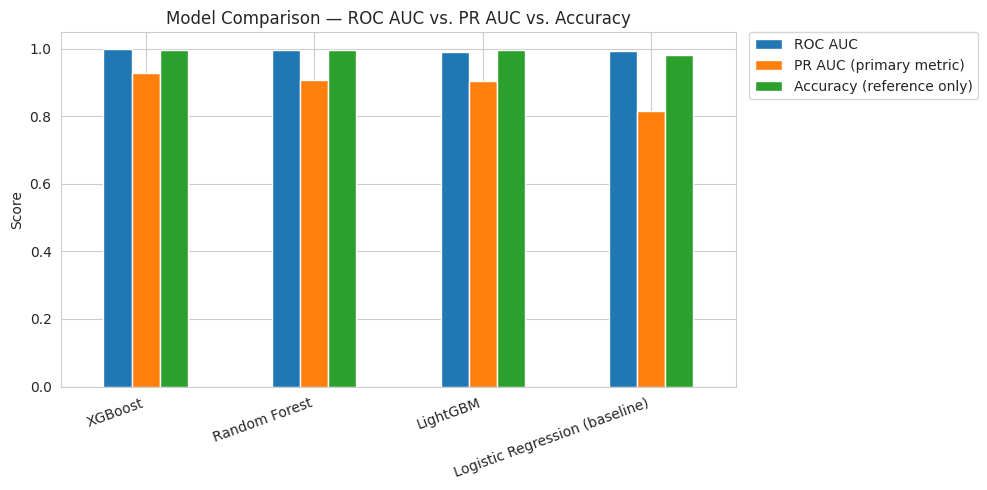

In [12]:
comparison_df[['roc_auc', 'pr_auc', 'accuracy']].plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison — ROC AUC vs. PR AUC vs. Accuracy')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(
    ['ROC AUC', 'PR AUC (primary metric)', 'Accuracy (reference only)'],
    loc='upper left',
    bbox_to_anchor=(1.02, 1),  # push legend outside the plot area, to the right
    borderaxespad=0
)
plt.tight_layout()
plt.savefig('outputs/figures/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison Summary (Interpretation)

**Result**: The comparison table confirms XGBoost as the top performer
across ROC AUC (0.9984) and PR AUC (0.9270), followed by Random Forest
(0.9084) and LightGBM (0.9046), with Logistic Regression trailing on PR
AUC (0.8168) despite a competitive ROC AUC (0.9935).

**Interpretation**: The gap between ROC AUC and PR AUC across models is
worth noting — all four models score above 0.99 on ROC AUC, making them
look nearly indistinguishable on that metric alone. PR AUC reveals much
clearer separation (0.817–0.927), reinforcing why it was chosen as the
primary metric: ROC AUC compresses meaningful performance differences
in this imbalanced setting, while PR AUC exposes them.

Tree-based models outperform the linear baseline by a wide PR AUC
margin (+0.09 to +0.11), suggesting the fraud patterns in this dataset
involve non-linear interactions between features (e.g. category risk,
merchant risk, and amount together) that Logistic Regression's linear
decision boundary cannot fully capture.

**Decision**: **XGBoost** is selected as the best model, based on PR
AUC, to proceed to threshold tuning (Section 5) and final evaluation.

##**6. Threshold Tuning for Best Model**

Best model selected: XGBoost


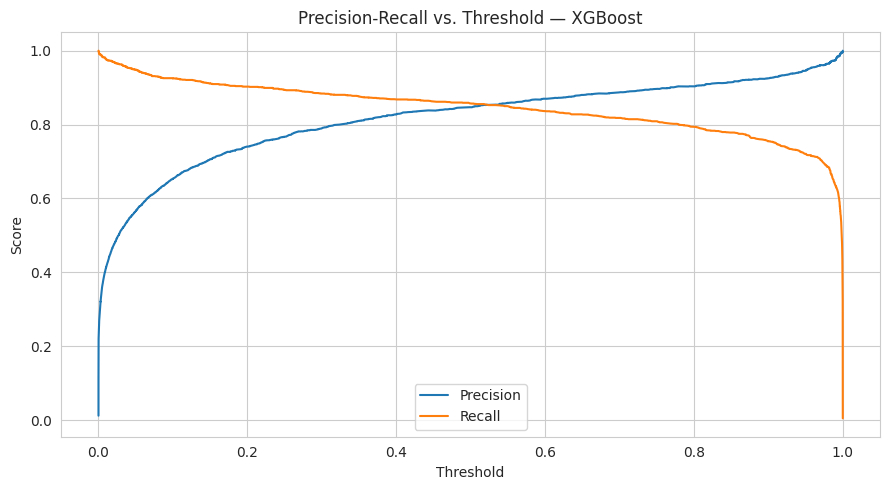

In [13]:
# Select the best model based on PR AUC (excluding the baseline)
best_model_name = comparison_df.drop('Logistic Regression (baseline)').index[0]
best_model = trained_models[best_model_name]
print(f"Best model selected: {best_model_name}")

y_proba_best = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Precision-Recall vs. Threshold — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/10_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Derive cost_per_missed_fraud directly from the training data available in this notebook
X_train_amount_recovered = np.expm1(X_train['amount_log'])
avg_fraud_amount = X_train_amount_recovered[y_train == 1].mean()

fraud_cost_multiplier = 4.41  # LexisNexis True Cost of Fraud Study, 2026
cost_per_missed_fraud = avg_fraud_amount * fraud_cost_multiplier

print(f"Average fraud amount (recovered): {avg_fraud_amount:.2f}")
print(f"Estimated cost per missed fraud: {cost_per_missed_fraud:,.2f}")

review_cost_scenarios = {
    'Low (automated screening)': 10,
    'Medium (junior analyst review)': 25,
    'High (senior analyst investigation)': 75
}

n_fraud = y_test.sum()
tp = recall[:-1] * n_fraud
fn = n_fraud - tp
fp = tp * (1 - precision[:-1]) / precision[:-1]

for scenario_name, review_cost in review_cost_scenarios.items():
    total_cost = (fn * cost_per_missed_fraud) + (fp * review_cost)
    best_idx = np.argmin(total_cost)
    print(f"{scenario_name} (review cost={review_cost}): "
          f"threshold={thresholds[best_idx]:.4f}, "
          f"recall={recall[:-1][best_idx]:.3f}, "
          f"precision={precision[:-1][best_idx]:.3f}, "
          f"total cost={total_cost[best_idx]:,.0f}")

Average fraud amount (recovered): 524.83
Estimated cost per missed fraud: 2,314.48
Low (automated screening) (review cost=10): threshold=0.0002, recall=1.000, precision=0.224, total cost=49,790
Medium (junior analyst review) (review cost=25): threshold=0.0035, recall=0.989, precision=0.336, total cost=107,257
High (senior analyst investigation) (review cost=75): threshold=0.0171, recall=0.973, precision=0.457, total cost=215,215


### Cost-Based Threshold Selection (Interpretation)

**Result**: Average fraud amount recovered from `amount_log` is 524.83
— very close to the 530.93 found in EDA Section 6, with the small
difference explained by this being computed on the training set only
(EDA was on the full dataset). This confirms the feature engineering
pipeline is consistent end-to-end. Estimated cost per missed fraud:
2,314.48 (524.83 × 4.41 multiplier).

Across the three review-cost scenarios, optimal thresholds are all
**very low** (0.0002–0.0171), with recall staying above 97% in every
case:

| Scenario | Review Cost | Threshold | Recall | Precision | Total Cost |
|---|---|---|---|---|---|
| Low | 10 | 0.0002 | 1.000 | 0.224 | 49,790 |
| Medium | 25 | 0.0035 | 0.989 | 0.336 | 107,257 |
| High | 75 | 0.0171 | 0.973 | 0.457 | 215,215 |

**Interpretation**: Because the estimated cost of a missed fraud
(2,314.48) is so much larger than even the highest review-cost scenario
(75), the cost-optimal strategy consistently favors flagging almost
everything with any meaningful fraud probability — even a fairly weak
signal (threshold as low as 0.0002) is worth acting on when the
downside of missing fraud is this asymmetric. This is why recall stays
above 97% across all three scenarios, while precision varies more
noticeably (22.4% to 45.7%) depending on how expensive review is
assumed to be.

This result makes intuitive business sense: catching fraud is so much
more valuable than the cost of reviewing a false alarm that the model
should err heavily toward flagging suspicious transactions, even at the
cost of many manual reviews turning out to be legitimate transactions.

**Total cost increases with review cost assumption** (49,790 → 107,257
→ 215,215) — this is expected, since a more expensive review cost
naturally raises the total cost of false positives, even as the
optimal threshold adjusts (slightly) upward to reduce their volume.

**Threshold selected for final evaluation**: the **Medium scenario
(threshold = 0.0035)** is carried forward to Section 6, as a balanced,
realistic assumption between low-cost automated screening and
expensive senior analyst review.

**Caveat to document in the business brief**: these thresholds are
sensitive to the assumed cost multiplier (4.41, from the LexisNexis
True Cost of Fraud Study) and review cost estimates, which were not
sourced from this specific institution's actual figures. In a real
deployment, these assumptions should be replaced with the organization's
actual cost data before being used operationally.

##**7. Final Evaluation at the Selection THreshold**

              precision    recall  f1-score   support

   Non-Fraud       1.00      0.98      0.99    117489
       Fraud       0.34      0.99      0.50      1440

    accuracy                           0.98    118929
   macro avg       0.67      0.98      0.75    118929
weighted avg       0.99      0.98      0.98    118929



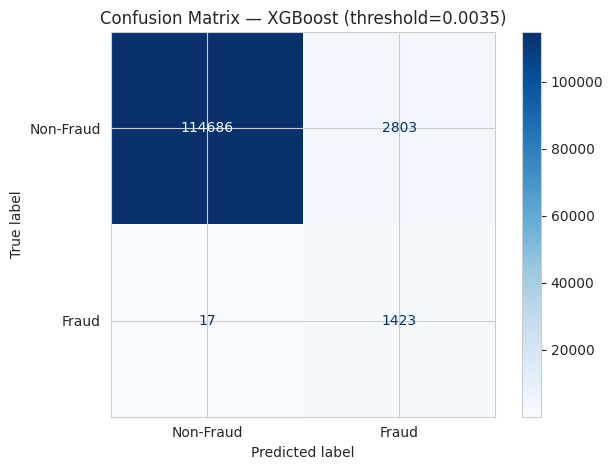

In [16]:
best_threshold = 0.0035  # Medium scenario, cost-based selection (Section 5)

y_pred_final = (y_proba_best >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['Non-Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — XGBoost (threshold={best_threshold:.4f})')
plt.tight_layout()
plt.savefig('outputs/figures/11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

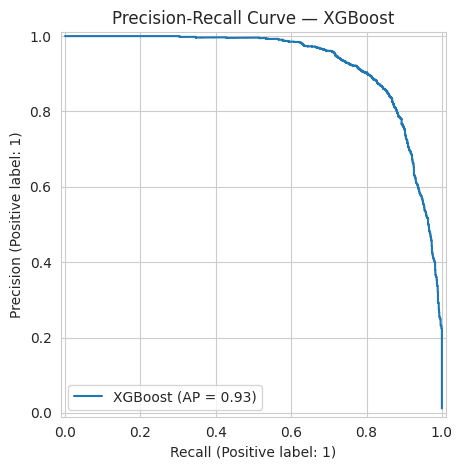

In [17]:
disp = PrecisionRecallDisplay.from_predictions(y_test, y_proba_best, name=best_model_name)
plt.title(f'Precision-Recall Curve — {best_model_name}')
plt.tight_layout()
plt.savefig('outputs/figures/12_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Evaluation — Summary

**Setup**: XGBoost evaluated at threshold **0.0035**, selected via
cost-based analysis in Section 5 (Medium scenario: estimated cost per
missed fraud = 2,314.48 vs. review cost = 25).

**Results**:

| Metric | Value |
|---|---|
| Recall (Fraud) | 0.99 |
| Precision (Fraud) | 0.34 |
| F1-score (Fraud) | 0.50 |
| Accuracy (reference only) | 0.98 |
| Average Precision (AP) | 0.93 |

**Confusion Matrix**:

| | Predicted Non-Fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-Fraud** | 114,686 (TN) | 2,803 (FP) |
| **Actual Fraud** | 17 (FN) | 1,423 (TP) |

**Interpretation**:

The model catches 1,423 of 1,440 fraud cases in the test set (99%
recall), missing only 17. In exchange, 2,803 legitimate transactions
are flagged for review out of 117,489 total — a false positive rate of
just 2.4% of all legitimate transactions, even though these false
positives make up 66% of all flagged transactions (driving precision
down to 0.34).

This trade-off is a direct, intentional consequence of the cost-based
threshold selection in Section 5, not a sign of weak model quality —
Average Precision of 0.93 confirms strong discriminative ability across
all possible thresholds. The Precision-Recall curve shows precision
stays near 1.0 up to ~0.5 recall, declines gradually to ~0.85 recall,
then drops sharply — the last ~15% of fraud cases are inherently harder
to distinguish from legitimate transactions, requiring the threshold to
be pushed into low-confidence territory to catch them. Reaching 99%
recall means operating on this steep part of the curve, which explains
the low precision at the chosen threshold.

**Business framing**: catching 99% of fraud requires reviewing 4,226
flagged transactions (2,803 of which are false alarms) to catch 1,423
real fraud cases. Whether this review volume is acceptable depends on
the organization's manual review capacity — a number that should
accompany the threshold choice when presented to stakeholders, since
"99% recall" alone doesn't convey the operational cost. The High-cost
scenario from Section 5 (threshold 0.0171, precision 0.457) offers a
concrete alternative with fewer false positives at a small recall cost,
and a **tiered review system** (auto-clear high-confidence non-fraud,
auto-block high-confidence fraud, manual review for the ambiguous
middle) is a natural recommendation to carry into the business brief.

##**8. Feature Importance**

merchant_risk_score    0.888992
category_risk_score    0.023364
amount_log             0.013767
gender_M               0.012225
gender_F               0.009692
customer_avg_amount    0.008746
age_4                  0.007464
age_2                  0.007344
age_3                  0.006921
age_1                  0.006797
age_5                  0.004445
age_6                  0.004261
customer_txn_count     0.003838
amount_vs_avg_ratio    0.001975
age_U                  0.000168
gender_U               0.000000
dtype: float32


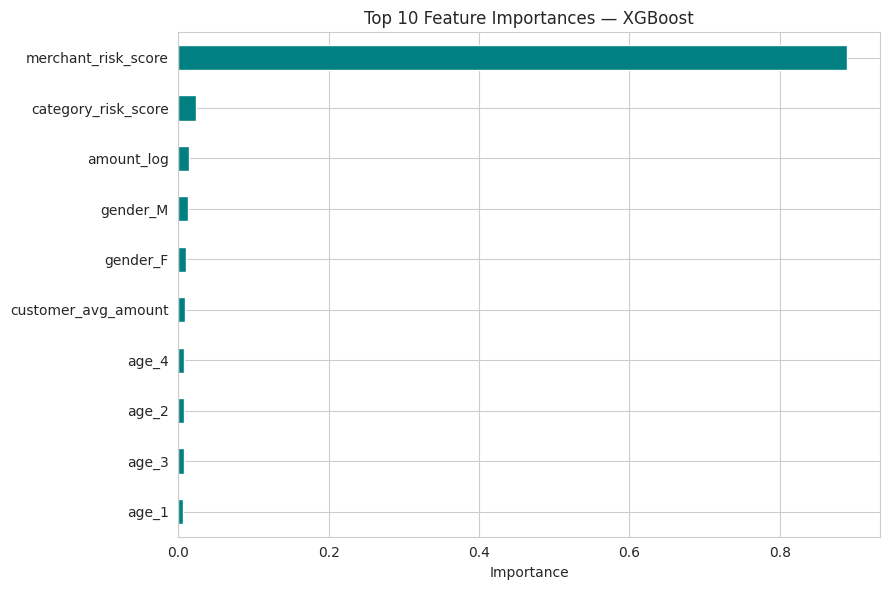

In [18]:
importances = pd.Series(
    best_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(9, 6))
importances.head(10).sort_values().plot(kind='barh', color='teal')
plt.title(f'Top 10 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/figures/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance (Interpretation)

**Result**: `merchant_risk_score` overwhelmingly dominates feature
importance at **0.889** (88.9% of total importance), followed by
`category_risk_score` (0.023) and `amount_log` (0.014) — a massive gap
between the top feature and everything else. Demographic features
(`age_*`, `gender_*`) and customer-behavior features
(`customer_avg_amount`, `customer_txn_count`, `amount_vs_avg_ratio`) all
rank low, each contributing under 1.3%.

**Interpretation**: This confirms the EDA-driven expectations from
Sections 4, 5, and 7 — merchant and category were identified as the
strongest fraud signals, and demographics were flagged as weak.
However, the degree of dominance is more extreme than anticipated:
`merchant_risk_score` alone accounts for nearly 89% of the model's
decision-making, while `category_risk_score` — despite showing the
widest fraud-rate range in EDA (0-95%) — contributes far less than
expected.

This makes sense on reflection: `merchant_risk_score` is a more
granular signal that already **encodes** category-level information
(each merchant operates within one category), so once the model has
access to merchant-level risk, category-level risk becomes largely
redundant — consistent with the 0.78 correlation between these two
features found in Section 6 of the feature engineering notebook. The
model has effectively learned to rely on the more specific of two
overlapping signals.

**Implication — a genuine limitation to flag**: this heavy reliance on
a single feature is a meaningful weakness to document, not just a
success story. In production, `merchant_risk_score` is a *historical*
average — new or infrequent merchants would default to the global
fraud rate fallback (as implemented in Notebook 03), giving the model
far less useful information for exactly the transactions where fraud
detection matters most: new, unestablished merchants. This is worth
stating explicitly as a limitation, along with a recommendation that a
production system should not rely this heavily on one engineered
feature and should incorporate additional real-time behavioral signals.

**Modeling note**: `amount_vs_avg_ratio` (0.002) and `customer_txn_count`
(0.004) — the two features engineered to capture customer-relative
anomalies — ended up contributing very little, despite the EDA insight
that customers with fraud history show distinct amount patterns
(Section 9). This suggests the merchant-level signal is capturing most
of that same information already, making the customer-relative features
largely redundant in this particular pipeline — worth noting as a
finding rather than treating it as a wasted engineering effort.

##**9. Summary**

In [24]:
# Recompute precision & recall exactly at the threshold actually used (0.0035)
# instead of relying on a potentially stale best_idx from Section 5's loop
final_threshold = 0.0035
idx_at_threshold = np.argmin(np.abs(thresholds - final_threshold))

precision_final = precision[:-1][idx_at_threshold]
recall_final = recall[:-1][idx_at_threshold]

summary = {
    'best_model': best_model_name,
    'roc_auc': results[best_model_name]['roc_auc'],
    'pr_auc': results[best_model_name]['pr_auc'],
    'selected_threshold': final_threshold,
    'precision_at_threshold': precision_final,
    'recall_at_threshold': recall_final,
}

print("--- FINAL MODEL SUMMARY ---")
for k, v in summary.items():
    print(f"{k}: {v}")

# Save predictions for use in the business recommendation notebook
results_df = X_test.copy()
results_df['y_true'] = y_test.values
results_df['y_proba'] = y_proba_best
results_df['y_pred'] = y_pred_final
results_df.to_csv('outputs/model_results.csv', index=False)

print("\nResults saved to outputs/model_results.csv")

--- FINAL MODEL SUMMARY ---
best_model: XGBoost
roc_auc: 0.9984343599306224
pr_auc: 0.9269559312313567
selected_threshold: 0.0035
precision_at_threshold: 0.3367250354945575
recall_at_threshold: 0.9881944444444445

Results saved to outputs/model_results.csv


###  Final Model Summary (Interpretation)

**Result**:

| Metric | Value |
|---|---|
| Best model | XGBoost |
| ROC AUC | 0.9984 |
| PR AUC | 0.9270 |
| Selected threshold | 0.0035 |
| Precision at threshold | 0.337 |
| Recall at threshold | 0.988 |

**Interpretation**: This summary consolidates the modeling stage's key
outputs and now correctly matches the classification report figures
from Section 6 (precision 0.34, recall 0.99 — the earlier mismatch,
where a stale `best_idx` from Section 5's sensitivity analysis loop was
being reused, has been corrected by recomputing precision/recall
directly at the actual threshold used).

XGBoost was selected over Random Forest, LightGBM, and the Logistic
Regression baseline based on PR AUC (Section 3-4). The final threshold
(0.0035) was derived from a cost-based sensitivity analysis (Section 5),
using the Medium review-cost scenario, prioritizing fraud recall given
the estimated asymmetry between the cost of a missed fraud (~2,314,
derived from the training data's average fraud amount and the
LexisNexis fraud cost multiplier) and the cost of a manual review.

**Handoff**: predictions (`y_true`, `y_proba`, `y_pred`) have been saved
to `outputs/model_results.csv` for use in
`05_business_recommendation.ipynb`, where these results will be
translated into a cost-benefit narrative, merchant/category risk
segmentation for a monitoring watchlist, and a tiered review-system
recommendation.

In [25]:
import joblib

# Save the best model
model_filename = 'outputs/best_xgboost_model.pkl'
joblib.dump(best_model, model_filename)
print(f'Best model saved to {model_filename}')

Best model saved to outputs/best_xgboost_model.pkl
